In [2]:
from hnn_core.optimization import Optimizer, add_opt_drives, set_params_opt_drives
import os.path as op

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import hnn_core
from hnn_core import (MPIBackend, jones_2009_model, simulate_dipole,
                      read_dipole, JoblibBackend)
from hnn_core.dipole import average_dipoles
from hnn_core.viz import plot_dipole

import pickle
import numpy as np
import sys

--No graphics will be displayed.


In [3]:
# 1) Load ERP waveform from CSV file
# ----------------------------------
# 1st column must be time in ms, 2nd column must be neural signal (e.g. nAm or or mV)
dipole_experimental = read_dipole('../data/BETA04_5mm_ROI_STC_100MT.txt')
dipole_experimental.times *= 1e3

In [4]:
# 2) Define optimization hyperparameters
# --------------------------------------
n_trials = 1  # Trials run per simulation, optimization loss is calculated on trial averaged waveform
scaling_factor = 1000  # Relevant for plotting, does not impact optimization with correlations objective function
window_length = 10  # Window size for smoothing (units as number of samples)
tstop = 300  # Simulation time in ms
dt = 0.025  # Time step of differential equation solver
max_iter = 100  # Maximum iterations of optimizer
popsize = 50  # Number of parameter sets per epoch (only relevant for CMA-ES)

obj_fun = "dipole_corr"  # Objective function to maximize correlation coefficient
solver = "cma"  # Covariance matrix adaption evolutionary strategy (CMA-ES)

# 2) Build network to be optimized and instantiate optimizer
# ----------------------------------------------------------
net_base = jones_2009_model()  # Variable to store the "base" network to be simulated

# This function adds extrinsic drives to the network in place (2 proximal and 1 distal drive).
# `constraints` is a dictionary with a unique key for every parameter in the drives that are added.
# The entries of constraints are tuples (low_val, high_val) defining the optimization bounds.
# `initial_params` is a dictionary with the same keys as `constraints`
constraints, initial_params = add_opt_drives(net_base, n_prox=3, n_dist=3)


lower_bounds = [bound[0] for bound in constraints.values()]
upper_bounds = [bound[1] for bound in constraints.values()]
cons_cma = [lower_bounds, upper_bounds]

sigma = 0.1 * (np.array(upper_bounds) - np.array(lower_bounds))

# Instantiate the optimization class with the network objects
# Note: `set_param_opt_drives()` is a function which complements `add_opt_drives()`. It uses the
# parameter keys in `constraints` to update the corresponding values in the network.
optim = Optimizer(net_base, tstop=tstop, constraints=constraints, solver=solver,
                    set_params=set_params_opt_drives, initial_params=initial_params, max_iter=max_iter, obj_fun=obj_fun)
                
# Run optimization
optim.fit(target=dipole_experimental, n_trials=n_trials, scale_factor=scaling_factor, sigma=sigma,
            smooth_window_len=window_length, dt=dt, popsize=popsize, n_jobs=50, verbose=0)





(25_w,50)-aCMA-ES (mu_w=14.0,w_1=14%) in dimension 66 (seed=118897, Fri Mar 20 16:23:11 2026)
(50, 66)


/oscar/home/ntolley/Jones_Lab/tep_opt/.pixi/envs/default/lib/python3.12/site-packages/hnn_core/optimization/general_optimization.py:101: UserWarning: The cma solver does not use initial_params.Values passed will not be used
  warn(
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No grap

Mean Loss: 0.96; Min Loss: 0.72
(50, 66)
Mean Loss: 0.91; Min Loss: 0.67
(50, 66)
Mean Loss: 0.88; Min Loss: 0.67
(50, 66)
Mean Loss: 0.82; Min Loss: 0.56
(50, 66)
Mean Loss: 0.75; Min Loss: 0.48
(50, 66)
Mean Loss: 0.67; Min Loss: 0.38
(50, 66)
Mean Loss: 0.69; Min Loss: 0.39
(50, 66)
Mean Loss: 0.70; Min Loss: 0.38
(50, 66)
Mean Loss: 0.73; Min Loss: 0.37
(50, 66)
Mean Loss: 0.74; Min Loss: 0.44
(50, 66)
Mean Loss: 0.66; Min Loss: 0.37
(50, 66)
Mean Loss: 0.70; Min Loss: 0.36
(50, 66)
Mean Loss: 0.69; Min Loss: 0.33
(50, 66)
Mean Loss: 0.66; Min Loss: 0.32
(50, 66)
Mean Loss: 0.62; Min Loss: 0.35
(50, 66)
Mean Loss: 0.68; Min Loss: 0.32
(50, 66)
Mean Loss: 0.61; Min Loss: 0.33
(50, 66)
Mean Loss: 0.67; Min Loss: 0.32
(50, 66)
Mean Loss: 0.62; Min Loss: 0.23
(50, 66)
Mean Loss: 0.61; Min Loss: 0.23
(50, 66)
Mean Loss: 0.63; Min Loss: 0.27
(50, 66)
Mean Loss: 0.63; Min Loss: 0.31
(50, 66)
Mean Loss: 0.64; Min Loss: 0.25
(50, 66)
Mean Loss: 0.62; Min Loss: 0.21
(50, 66)
Mean Loss: 0.59;

In [5]:
# 3) Evalute and save optimization results
# -----------------------------------------
# Save parameters of best fit network
optim.net_.write_configuration('../data/opt_config_correlation.json')

# Save optimizer class
with open('../data/opt_object_correlation.json', 'wb') as file:
    pickle.dump(optim, file)


# Run best fit dipole:
with JoblibBackend(n_jobs=10):
    dipoles_optimized = simulate_dipole(
            optim.net_, tstop=tstop, n_trials=n_trials, dt=dt)



--No graphics will be displayed.


Text(0.5, 1.0, 'Best loss: 0.08')

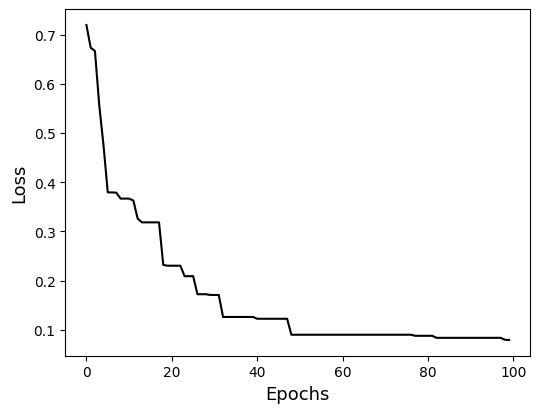

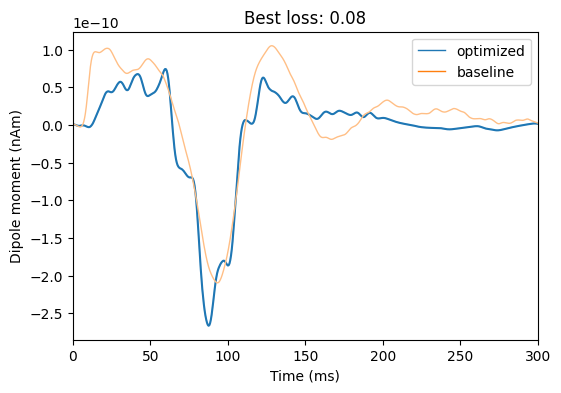

In [6]:
# Smooth and scale
opt_scale = np.std(dipole_experimental.data['agg']) / np.std(dipoles_optimized[0].data['agg']) 

plot_dipoles = list()
for dipole in dipoles_optimized:
    plot_dipoles.append(dipole.copy().smooth(window_length).scale(opt_scale))

# Make figures
labelsize = 13
ticksize = 10

# Loss figure
plt.figure(figsize=(6,4.5))
plt.plot(optim.obj_, color='k')
plt.xlabel('Epochs', fontsize=labelsize)
plt.ylabel('Loss', fontsize=labelsize)
plt.xticks(fontsize=ticksize)
plt.xticks(fontsize=ticksize)
# plt.savefig(f'/users/ntolley/Jones_Lab/hnn_jove/figures/baseline_optimization/opt_baseline_loss_{job_id}.png')

# Dipole figure
fig, ax = plt.subplots(sharex=True, figsize=(6,4))
plot_dipole(plot_dipoles.copy(), ax=ax, layer='agg',
            show=False, color='tab:blue', average=True)
dipole_experimental.plot(ax=ax, layer='agg', show=False,
                        color='tab:orange')
# Legend
legend_handles = [Line2D([0], [0], color='tab:blue', lw=1.0),
                Line2D([0], [0], color='tab:orange', lw=1.0),
                Line2D([0], [0], color='tab:green', lw=1.0)]
ax.legend(legend_handles, ['optimized', 'baseline'])
plt.title(f'Best loss: {optim.obj_[-1]:.2f}')

# plt.savefig(f'/users/ntolley/Jones_Lab/hnn_jove/figures/baseline_optimization/opt_baseline_dipole_{job_id}.png')